In [11]:
import numpy as np

np.array([1, 2, 3])[np.newaxis, :] - np.array([1, 1, 3])

array([[0, 1, 0]])

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, List

@torch.no_grad()
def _iter_dataloader_loss(model: nn.Module,
                          criterion: nn.Module,
                          loader,
                          device: torch.device,
                          max_batches: Optional[int] = None) -> float:

    total, n = 0.0, 0
    for bi, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        loss = criterion(model(x), y)
        bs = x.shape[0]
        total += float(loss) * bs
        n += bs
        if max_batches is not None and (bi + 1) >= max_batches:
            break
    return total / max(1, n)

def _module_kind(module: nn.Module) -> str:
    if isinstance(module, (nn.Conv1d, nn.Conv2d, nn.Conv3d)): return "conv"
    if isinstance(module, nn.Linear): return "linear"
    return "other"

def _collect_params(model: nn.Module) -> List[Tuple[str, nn.Parameter, str]]:
    out = []
    for mod_name, mod in model.named_modules():
        kind = _module_kind(mod)
        for pname, p in mod.named_parameters(recurse=False):
            if p.requires_grad:
                full = f"{mod_name}.{pname}" if mod_name else pname
                out.append((full, p, kind))
    return out

def _filterwise_normalized_direction(param: torch.Tensor,
                                     kind: str,
                                     is_weight: bool) -> torch.Tensor:
    d = torch.randn_like(param)
    if kind == "conv" and is_weight and param.ndim >= 3:
        d = d.reshape(param.shape[0], -1)
        p = param.reshape(param.shape[0], -1)
        d = (d / (d.norm(dim=1, keepdim=True) + 1e-12)) * p.norm(dim=1, keepdim=True)
        return d.reshape_as(param)
    if kind == "linear" and is_weight and param.ndim == 2:
        d = d / (d.norm(dim=1, keepdim=True) + 1e-12) * param.norm(dim=1, keepdim=True)
        return d
    if (kind in ("conv", "linear")) and not is_weight and param.ndim == 1:
        return d / (d.abs() + 1e-12) * param.abs()
    return torch.zeros_like(param)

def _make_two_directions(model: nn.Module) -> Tuple[Dict[str, torch.Tensor], Dict[str, torch.Tensor]]:
    d1, d2 = {}, {}
    for full, p, kind in _collect_params(model):
        is_weight = full.endswith(".weight")
        d1[full] = _filterwise_normalized_direction(p, kind, is_weight)
        d2[full] = _filterwise_normalized_direction(p, kind, is_weight)
    return d1, d2

@torch.no_grad()
def _apply_perturbation_(model: nn.Module,
                         base: Dict[str, torch.Tensor],
                         d1: Dict[str, torch.Tensor],
                         d2: Dict[str, torch.Tensor],
                         alpha: float, beta: float):
    for full, p, _ in _collect_params(model):
        p.data.copy_(base[full] + alpha * d1[full] + beta * d2[full])

def snapshot_params(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {full: p.detach().clone() for (full, p, _) in _collect_params(model)}

def loss_landscape_2d(model: nn.Module,
                      criterion: nn.Module,
                      loader,
                      device: Optional[torch.device] = None,
                      grid_n: int = 41,
                      radius_alpha: float = 1.0,
                      radius_beta: float = 1.0,
                      max_batches: Optional[int] = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if device is None:
        device = next(model.parameters()).device
    model.to(device)
    base = snapshot_params(model)
    d1, d2 = _make_two_directions(model)
    for d in (d1, d2, base):
        for k in d:
            d[k] = d[k].to(device)

    alphas = torch.linspace(-radius_alpha, radius_alpha, grid_n)
    betas  = torch.linspace(-radius_beta,  radius_beta,  grid_n)
    Z = torch.empty((grid_n, grid_n), dtype=torch.float64)

    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            _apply_perturbation_(model, base, d1, d2, float(a), float(b))
            Z[j, i] = _iter_dataloader_loss(model, criterion, loader, device, max_batches=max_batches)

    _apply_perturbation_(model, base, d1, d2, 0.0, 0.0)
    A, B = torch.meshgrid(alphas, betas, indexing="xy")
    return A, B, Z

def plot_landscape(A: torch.Tensor, B: torch.Tensor, Z: torch.Tensor, levels: int = 50, title: Optional[str] = None):
    plt.figure()
    cs = plt.contourf(A.cpu().numpy(), B.cpu().numpy(), Z.cpu().numpy(), levels=levels)
    plt.colorbar(cs)
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$\beta$")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

def plot_landscape_3d(A: torch.Tensor, B: torch.Tensor, Z: torch.Tensor,
                      title: Optional[str] = None, stride: int = 1):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A.cpu().numpy(),
                    B.cpu().numpy(),
                    Z.cpu().numpy(),
                    cmap=cm.viridis,
                    rstride=stride,
                    cstride=stride,
                    linewidth=0,
                    antialiased=True)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_zlabel("Loss")
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [2]:
import torch.nn as nn
from torch.utils.data import SubsetRandomSampler, Subset, DataLoader
import numpy as np

from liquid.train import load_protein
from liquid.citizens.citizen import get_sequential


d_train, d_test = load_protein()
d_subset = Subset(d_train, np.random.choice(len(d_train), replace=False, size=300))
model = get_sequential([9, 30, 30, 30, 1], last_linear=True, dropout=0.3)

criterion = nn.MSELoss()
loader = DataLoader(d_subset, batch_size=300)

In [3]:
%matplotlib widget

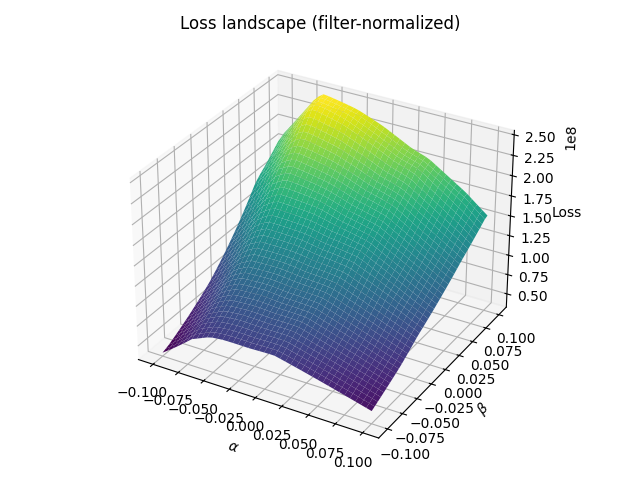

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device).eval()


A, B, Z = loss_landscape_2d(model, criterion, loader, device,
                            grid_n=41, radius_alpha=0.1, radius_beta=0.1)  # use max_batches to speed up

plot_landscape_3d(A, B, Z, title="Loss landscape (filter-normalized)")